In [ ]:
import os
from nilearn import plotting, image
from nilearn.maskers import NiftiLabelsMasker
from nilearn.masking import apply_mask, unmask
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import nibabel as nb
import pandas as pd
from nilearn.image import load_img
from nilearn import plotting, datasets, surface
import matplotlib.pyplot as plt
import numpy as np

windows= True   

#paths
if windows:
    base_dir = "P:/workspaces/lg-ukbiobank/projects/"
else:
    base_dir = "/data/workspaces/lag/workspaces/lg-ukbiobank/projects/"
nifti_path=os.path.join(base_dir, "nifti_avg")
neurosynth_fn=os.path.join(base_dir, "language_association-test_z_FDR_0.01_231027.nii.gz")


## Functions

In [2]:
def plot_surface_maps_fig_1(img_list, mask_list, output_file=None, cmap_list = None, 
                      symmetric_cbar=True, pmap_mask=False, cmap_mask=True, thresholds=None):
    """
    Plot multiple nifti files on brain surface views.
    
    Parameters:
    -----------
    map_dict : dict
        Dictionary with map names as keys and file paths as values
    output_file : str, optional
        Path to save the figure. If None, the figure is displayed but not saved
    view : str or list, optional
        View angle for the surface plots ('lateral', 'medial', 'dorsal', 'ventral')
    cmap : str, optional
        Colormap for the surface plots
    symmetric_cbar : bool, optional
        Whether to make the colorbar symmetric around 0
    threshold : float, optional
        Threshold for the displayed values
        
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The figure object
    """
    # Load fsaverage surface
    if not cmap_list:
        cmap_list = ["cold_hot"] * len(img_list)

    if not thresholds:
        thresholds = [1e-4] * len(img_list)

    fsaverage = datasets.fetch_surf_fsaverage()
    
    
    # Create figure
    fig, ax = plt.subplots( nrows=len(img_list),
                           ncols = 4,
                           figsize=(18, len(img_list)*3),
                           subplot_kw={"projection": "3d"} )
    
    for i in range(len(img_list)):
        cmap=cmap_list[i]
        threshold=thresholds[i]

        # Project image to surface FIRST
        if isinstance(img_list[i], str):
            img_vol = load_img(img_list[i])
        else:
            img_vol = img_list[i]
        
        print(np.abs(np.max(img_vol.get_fdata())))
            
        surf_data_left = surface.vol_to_surf(img_vol, fsaverage['pial_left'])
        surf_data_right = surface.vol_to_surf(img_vol, fsaverage['pial_right'])
        
        # Project mask to surface
        mask_surf_left = surface.vol_to_surf(mask_list[i], fsaverage['pial_left'])
        mask_surf_right = surface.vol_to_surf(mask_list[i], fsaverage['pial_right'])
        
        # Apply mask on surface (more aggressive thresholding)
        mask_surf_left = (mask_surf_left > 0.15).astype(float) 
        mask_surf_right = (mask_surf_right > 0.15).astype(float)
        
        if pmap_mask[i] == True:
        # Set areas within mask to zero (inverse masking)
            surf_data_left = surf_data_left * (1 - mask_surf_left)
            surf_data_right = surf_data_right * (1 - mask_surf_right)
        else:
            surf_data_left = surf_data_left * mask_surf_left
            surf_data_right = surf_data_right * mask_surf_right

        plotting.plot_surf_stat_map(
                fsaverage['pial_left'],
                surf_data_left,
                hemi='left',
                view='lateral',
                bg_map=fsaverage['sulc_left'],
                bg_on_data=True,
                darkness=0.5,
                axes=ax[i, 0],
                cmap=cmap,
                colorbar=False,
                threshold=threshold
            )
        
        plotting.plot_surf_stat_map(
                fsaverage['pial_left'],
                surf_data_left,
                hemi='left',
                view='medial',
                bg_map=fsaverage['sulc_left'],
                bg_on_data=True,
                darkness=0.5,
                axes=ax[i, 1],
                cmap=cmap,
                colorbar=False,
                threshold=threshold
            )
            
        plotting.plot_surf_stat_map(
                fsaverage['pial_right'],
                surf_data_right,
                hemi='right',
                view='lateral',
                bg_map=fsaverage['sulc_right'],
                bg_on_data=True,
                darkness=0.5,
                axes=ax[i, 2],
                cmap=cmap,
                colorbar=False,
                threshold=threshold
            )
            
        plotting.plot_surf_stat_map(
                fsaverage['pial_right'],
                surf_data_right,
                hemi='right',
                view='medial',
                bg_map=fsaverage['sulc_right'],
                bg_on_data=True,
                darkness=0.5,
                axes=ax[i, 3],
                cmap=cmap,
                colorbar=False,
                threshold=threshold
            )
        
    plt.tight_layout()
    
    # Save figure if output file is specified
    if output_file:
        fig.savefig(output_file, dpi=400, bbox_inches='tight')
    
    return fig

# Main PMAPS

15.920949754104074
0.012753685005009174


c:\Users\Jitse\.conda\envs\neuro\Lib\site-packages\nilearn\plotting\surf_plotting.py:582: RuntimeWarning: invalid value encountered in divide
  data_copy /= vmax - vmin


8342.4853515625
0.017273686826229095


c:\Users\Jitse\.conda\envs\neuro\Lib\site-packages\nilearn\plotting\surf_plotting.py:582: RuntimeWarning: invalid value encountered in divide
  data_copy /= vmax - vmin


3828.666259765625
15.920949754104074
0.012753685005009174


c:\Users\Jitse\.conda\envs\neuro\Lib\site-packages\nilearn\plotting\surf_plotting.py:582: RuntimeWarning: invalid value encountered in divide
  data_copy /= vmax - vmin


8342.4853515625
0.017273686826229095


c:\Users\Jitse\.conda\envs\neuro\Lib\site-packages\nilearn\plotting\surf_plotting.py:582: RuntimeWarning: invalid value encountered in divide
  data_copy /= vmax - vmin


3828.666259765625


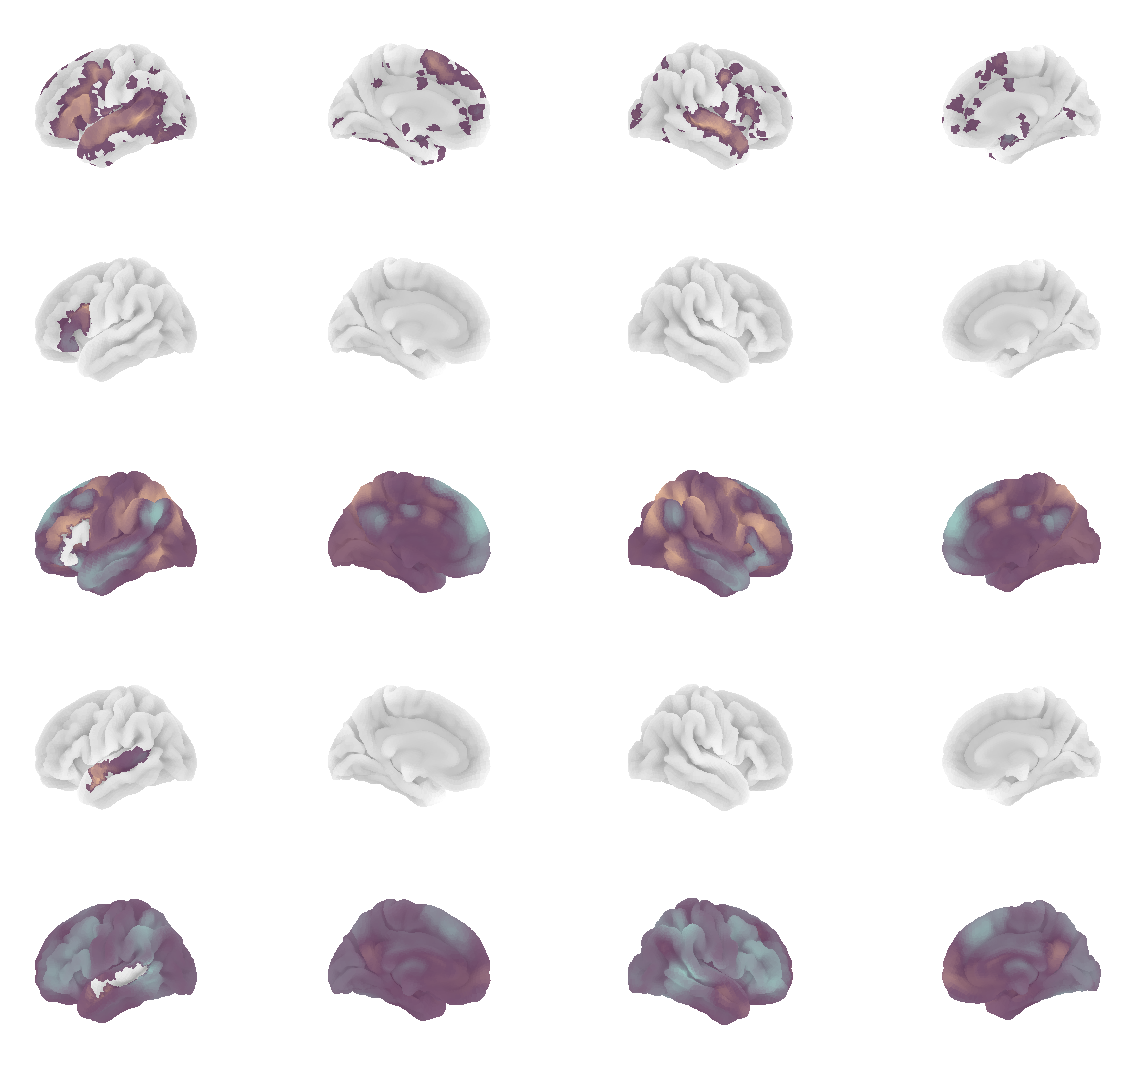

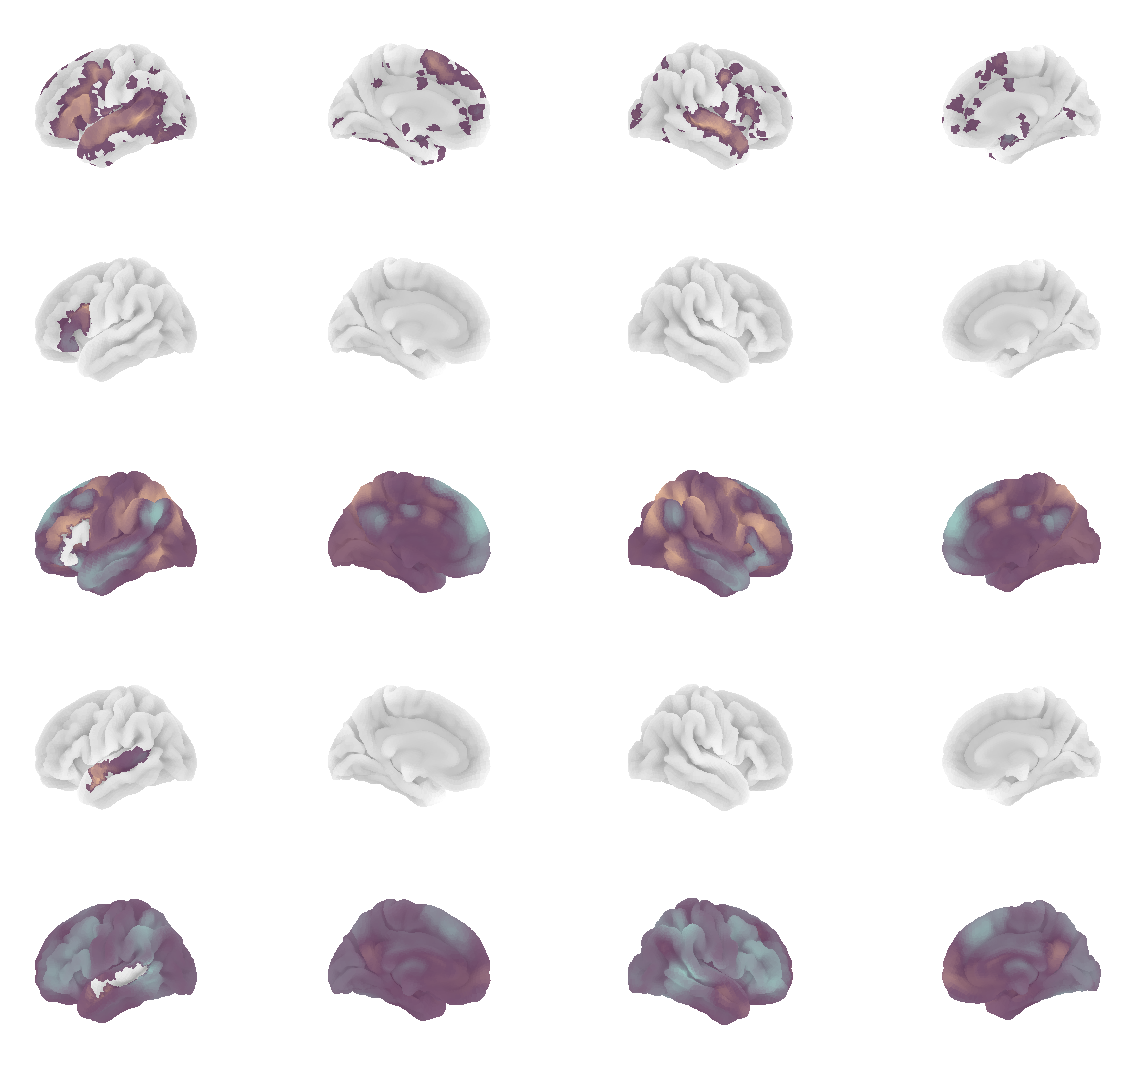

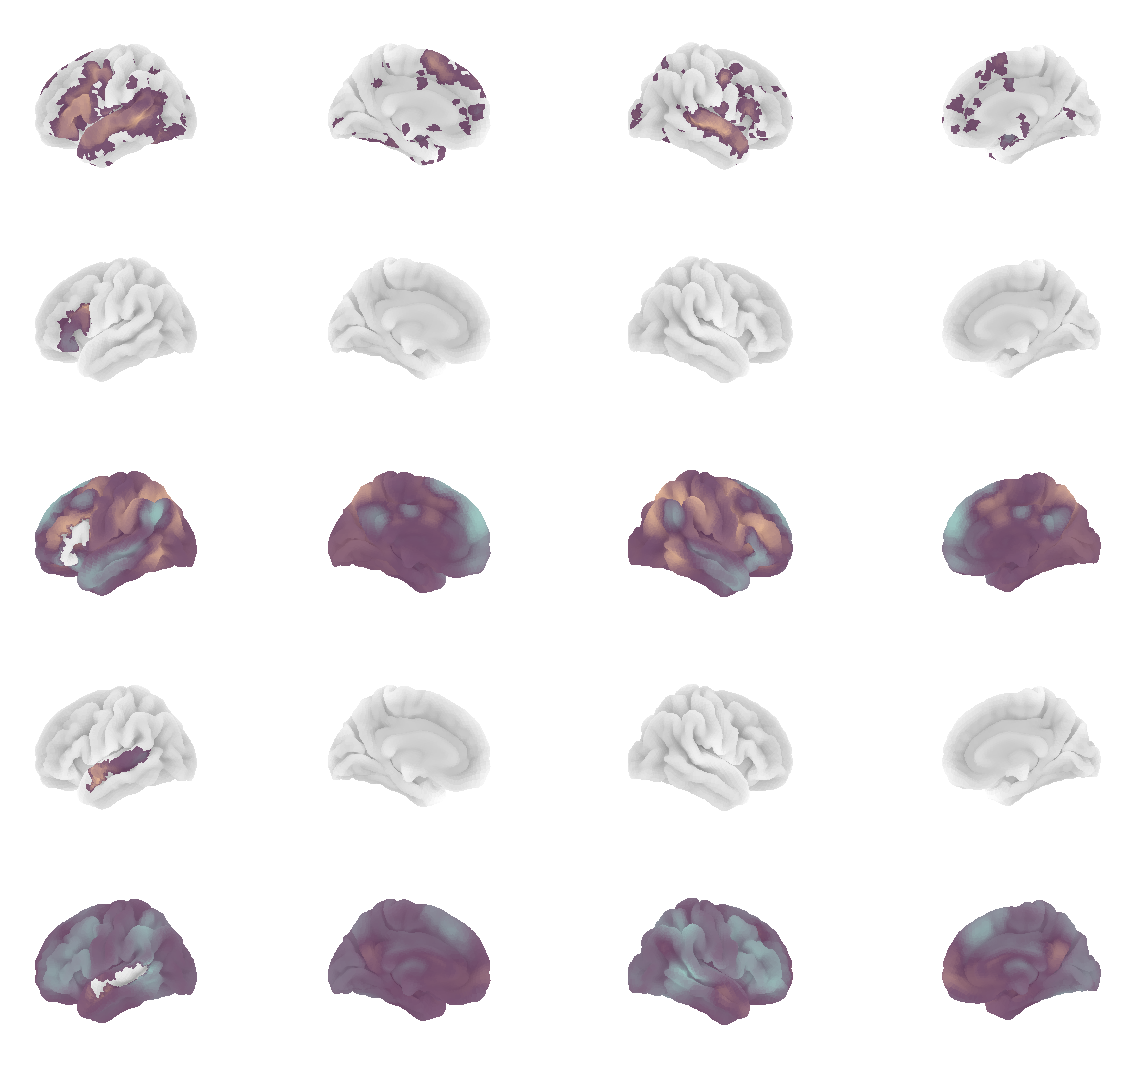

In [ ]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from nilearn import datasets

cmap_new = ["#7F206E", "#EEEEEE", "#00483F" ]
#colors = ["#214D9D", "whitesmoke", "#AA1926"]

# green to white to orange
#colors = [ '#ED6B06',  "whitesmoke", '#00786A']

#lightgreen to darkpurple to lightorange
colors = ["#80BBB4",  "#4B1742", "#F7B682"]

#green to lightpurple to orange
#colors = ["#00786A" "#BF8FB6"  "#ED6B06"]

#color_list_comps = ['#80BBB4', ,, '#F7B682', , ]
#colors = ["#214D9D", "whitesmoke",  "#00786A"]
palette = LinearSegmentedColormap.from_list("custom_palette", colors)
cmap1 = LinearSegmentedColormap.from_list("mycmap", cmap_new)

base_dir = r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat"
#nifti_path = os.path.join(base_dir, "nifti_avg")
nifti_path = r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\to_laptop\ic_maps"
neurosynth_fn = os.path.join(base_dir, "language_association-test_z_FDR_0.01_231027.nii.gz")



lifg_img = os.path.join(nifti_path, "g1_pmap_lifg_oIC.nii.gz")
lstg_img = os.path.join(nifti_path, "g1_pmap_lstg_oIC.nii.gz")

lifg_g2_img = os.path.join(nifti_path, "g2_pmap_lifg_oIC.nii.gz")
lstg_g2_img = os.path.join(nifti_path, "g2_pmap_lstg_oIC.nii.gz")

nii_files = [os.path.join(base_dir, "mean_gs", "all_data_lifg_g1_cmap_mean.nii.gz"),
             os.path.join(base_dir, "mean_gs", "all_data_lifg_g1_pmap_mean.nii.gz"),
             os.path.join(base_dir, "mean_gs", "all_data_lstg_g1_cmap_mean.nii.gz"),
             os.path.join(base_dir, "mean_gs", "all_data_lstg_g1_pmap_mean.nii.gz")]

img_list = [os.path.join(os.path.join(base_dir,"language_association-test_z_FDR_0.01_231027.nii.gz"))] + nii_files
#cmap_list = ["cold_hot"] + [cmap1] * len(nii_files)

mask_files = [datasets.load_mni152_brain_mask(),
              os.path.join(base_dir, "masks", "roi_lifg.nii.gz"),
              os.path.join(base_dir, "masks", "roi_lifg.nii.gz"),
              os.path.join(base_dir, "masks", "roi_lstg.nii.gz"),
              os.path.join(base_dir, "masks", "roi_lstg.nii.gz")]

plot_surface_maps_fig_1(img_list = img_list,
                        mask_list= mask_files,
                        cmap_list = [palette] * len(img_list),
                        output_file=os.path.join(base_dir, "figs_new", "fig_1_brain_maps_masked.png"),
                        pmap_mask= [False, False, True, False, True],
                        thresholds=[1e-6] * len(img_list) )

plot_surface_maps_fig_1(img_list = img_list,
                        mask_list= mask_files,
                        cmap_list = [palette] * len(img_list),
                        output_file=os.path.join(base_dir, "figs_new", "fig_1_brain_maps_masked.svg"),
                        pmap_mask= [False, False, True, False, True],
                        thresholds=[1e-6] * len(img_list) )

In [4]:
nii_files = [r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\to_laptop\mean_gs\all_data_lifg_g1_cmap_mean.nii.gz",
             r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\to_laptop\mean_gs\all_data_lifg_g1_pmap_mean.nii.gz",
             r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\to_laptop\mean_gs\all_data_lstg_g1_cmap_mean.nii.gz",
             r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\to_laptop\mean_gs\all_data_lstg_g1_pmap_mean.nii.gz"]

for nii in nii_files:
    print(nii)
    data = load_img(nii).get_fdata()
    print(np.max(np.abs(data)))

C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\to_laptop\mean_gs\all_data_lifg_g1_cmap_mean.nii.gz
0.012753685005009174
C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\to_laptop\mean_gs\all_data_lifg_g1_pmap_mean.nii.gz
9140.4404296875
C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\to_laptop\mean_gs\all_data_lstg_g1_cmap_mean.nii.gz
0.017273686826229095
C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\to_laptop\mean_gs\all_data_lstg_g1_pmap_mean.nii.gz
6145.3076171875


In [ ]:


nii_files = [os.path.join(base_dir, "mean_gs", "all_data_lifg_g2_cmap_mean.nii.gz"),
             os.path.join(base_dir, "mean_gs", "all_data_lifg_g2_pmap_mean.nii.gz"),
             os.path.join(base_dir, "mean_gs", "all_data_lstg_g2_cmap_mean.nii.gz"),
             os.path.join(base_dir, "mean_gs", "all_data_lstg_g2_pmap_mean.nii.gz")]

for nii in nii_files:
    print(nii)
    data = load_img(nii).get_fdata()
    print(np.max(np.abs(data)))

C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\to_laptop\mean_gs\all_data_lifg_g2_cmap_mean.nii.gz
0.020339729264378548
C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\to_laptop\mean_gs\all_data_lifg_g2_pmap_mean.nii.gz
10430.5
C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\to_laptop\mean_gs\all_data_lstg_g2_cmap_mean.nii.gz
0.014177612960338593
C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\to_laptop\mean_gs\all_data_lstg_g2_pmap_mean.nii.gz
5862.11376953125


In [ ]:
lifg_img = os.path.join(nifti_path, "g1_pmap_lifg_oIC.nii.gz")
lstg_img = os.path.join(nifti_path, "g1_pmap_lstg_oIC.nii.gz")

nii_files = [image.index_img(lifg_img, 0),
             image.index_img(lifg_img, 1),
             image.index_img(lifg_img, 2),
             image.index_img(lstg_img, 0),
             image.index_img(lstg_img, 1),
             image.index_img(lstg_img, 2)]


for nii in nii_files:
    data = nii.get_fdata()
    print(np.max(np.abs(data)))

6766.92138671875
6623.2529296875
4509.8818359375
5482.61669921875
3167.983154296875
3265.2939453125


In [ ]:
lifg_img = os.path.join(nifti_path, "g2_pmap_lifg_oIC.nii.gz")
lstg_img = os.path.join(nifti_path, "g2_pmap_lstg_oIC.nii.gz")

nii_files = [image.index_img(lifg_img, 0),
             image.index_img(lifg_img, 1),
             image.index_img(lifg_img, 2),
             image.index_img(lstg_img, 0),
             image.index_img(lstg_img, 1),
             image.index_img(lstg_img, 2)]


for nii in nii_files:
    data = nii.get_fdata()
    print(np.max(np.abs(data)))

6655.9482421875
6645.923828125
4052.612548828125
5996.78076171875
3538.814697265625
3891.433837890625


0.020339729264378548


c:\Users\Jitse\.conda\envs\neuro\Lib\site-packages\nilearn\plotting\surf_plotting.py:582: RuntimeWarning: invalid value encountered in divide
  data_copy /= vmax - vmin


10430.5
0.00777386175468564


c:\Users\Jitse\.conda\envs\neuro\Lib\site-packages\nilearn\plotting\surf_plotting.py:582: RuntimeWarning: invalid value encountered in divide
  data_copy /= vmax - vmin


5862.11376953125
0.020339729264378548


c:\Users\Jitse\.conda\envs\neuro\Lib\site-packages\nilearn\plotting\surf_plotting.py:582: RuntimeWarning: invalid value encountered in divide
  data_copy /= vmax - vmin


10430.5
0.00777386175468564


c:\Users\Jitse\.conda\envs\neuro\Lib\site-packages\nilearn\plotting\surf_plotting.py:582: RuntimeWarning: invalid value encountered in divide
  data_copy /= vmax - vmin


5862.11376953125


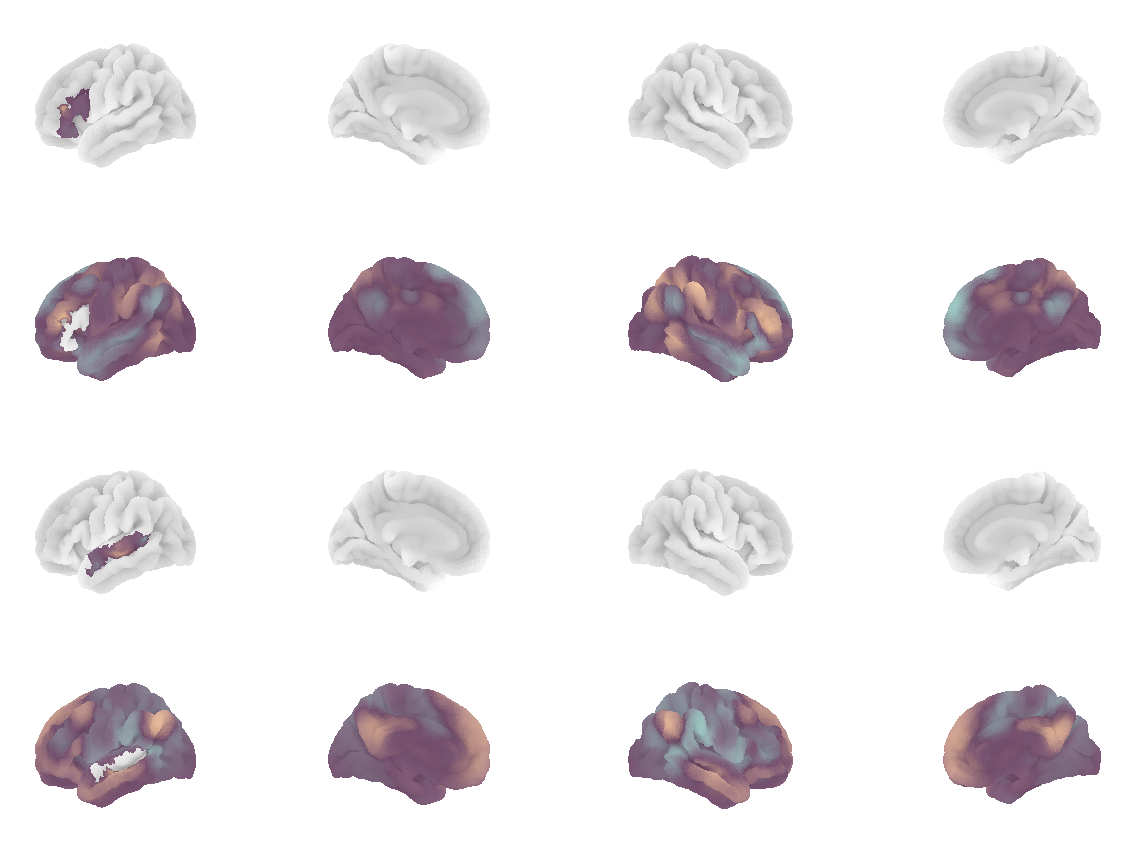

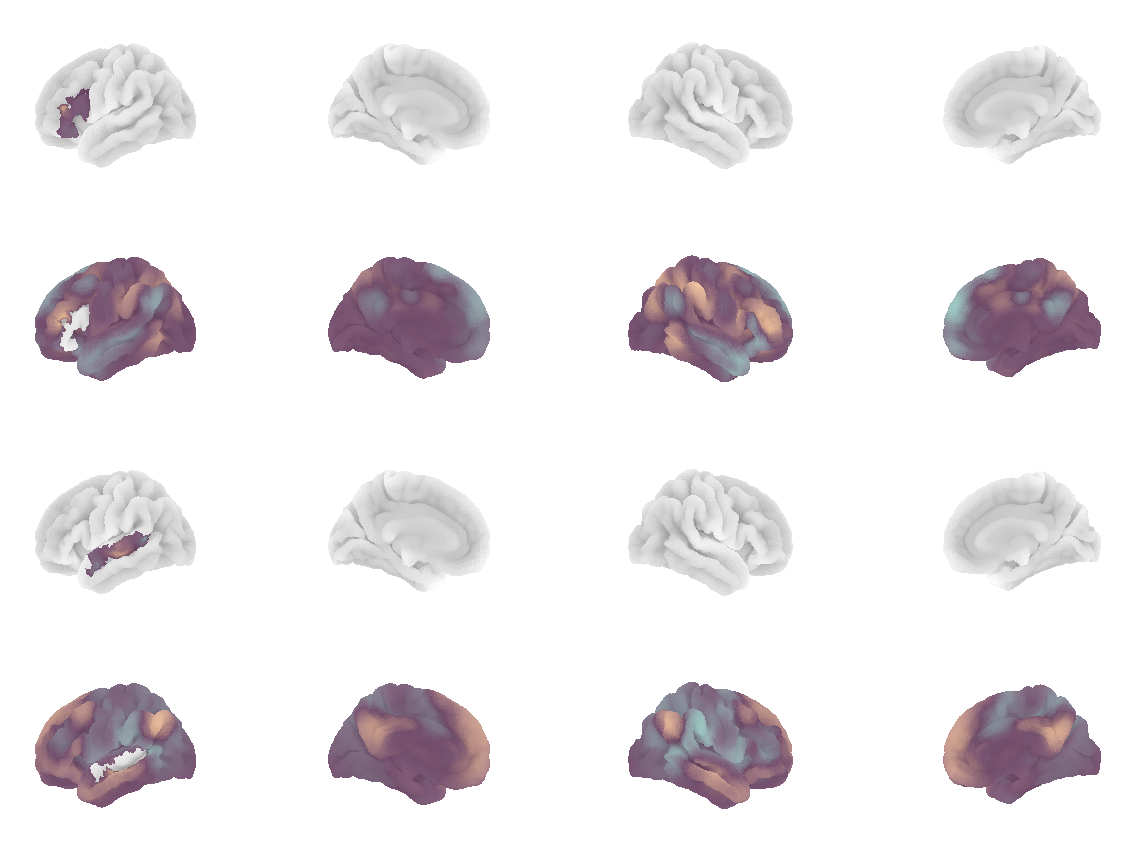

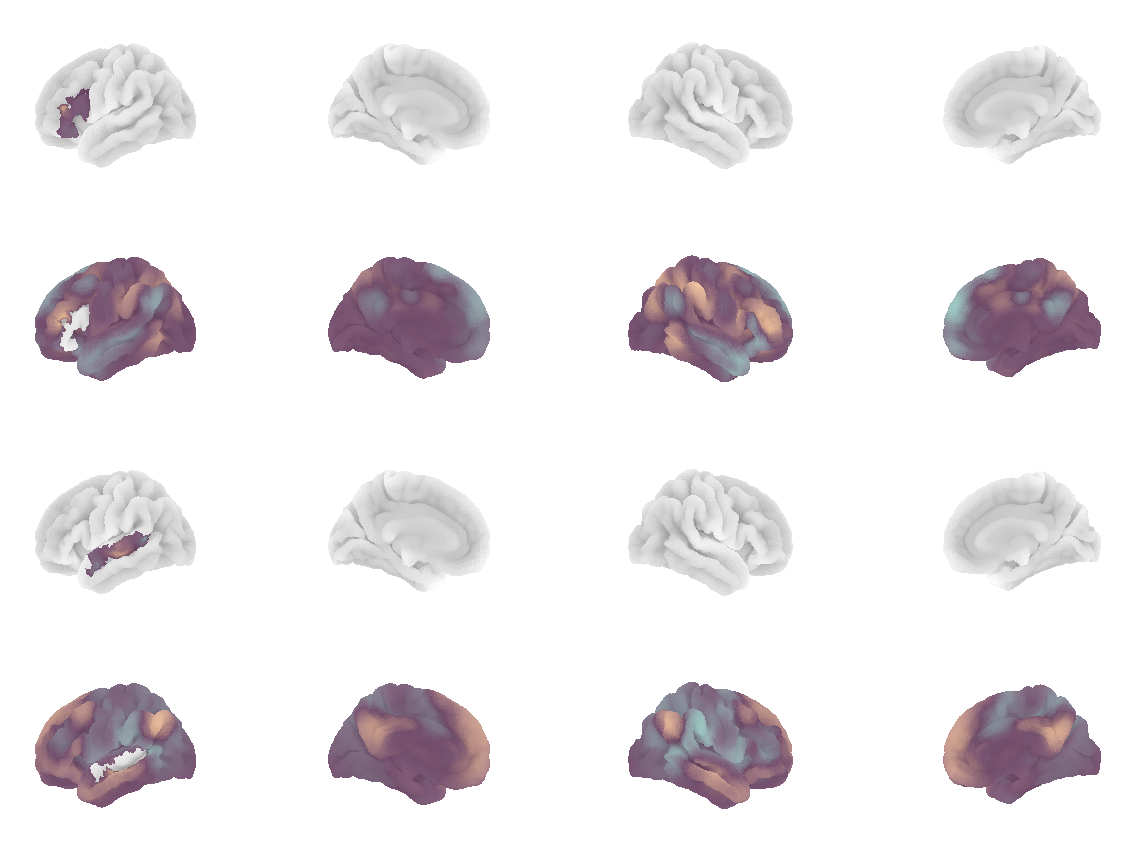

In [ ]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from nilearn import datasets

cmap_new = ["#7F206E", "#EEEEEE", "#00483F" ]
#colors = ["#214D9D", "whitesmoke", "#AA1926"]

# green to white to orange
#colors = [ '#ED6B06',  "whitesmoke", '#00786A']

#lightgreen to darkpurple to lightorange
colors = ["#80BBB4",  "#4B1742", "#F7B682"]

#green to lightpurple to orange
#colors = ["#00786A" "#BF8FB6"  "#ED6B06"]

#color_list_comps = ['#80BBB4', ,, '#F7B682', , ]
#colors = ["#214D9D", "whitesmoke",  "#00786A"]
palette = LinearSegmentedColormap.from_list("custom_palette", colors)
cmap1 = LinearSegmentedColormap.from_list("mycmap", cmap_new)

nii_files = [os.path.join(base_dir, "mean_gs", "all_data_lifg_g2_cmap_mean.nii.gz"),
             os.path.join(base_dir, "mean_gs", "all_data_lifg_g2_pmap_mean.nii.gz"),
             os.path.join(base_dir, "mean_gs", "all_data_lstg_g2_cmap_mean.nii.gz"),
             os.path.join(base_dir, "mean_gs", "all_data_lstg_g2_pmap_mean.nii.gz")]

#img_list = [os.path.join(os.path.join(base_dir,"language_association-test_z_FDR_0.01_231027.nii.gz"))] + nii_files
img_list = nii_files
#cmap_list = ["cold_hot"] + [cmap1] * len(nii_files)

mask_files = [os.path.join(base_dir, "masks", "roi_lifg.nii.gz"),
              os.path.join(base_dir, "masks", "roi_lifg.nii.gz"),
              os.path.join(base_dir, "masks", "roi_lstg.nii.gz"),
              os.path.join(base_dir, "masks", "roi_lstg.nii.gz")]

plot_surface_maps_fig_1(img_list = img_list,
                        mask_list= mask_files,
                        cmap_list = [palette] * len(img_list),
                        output_file=os.path.join(base_dir, "figs_new", "fig_1_brain_maps_g2_masked.png"),
                        pmap_mask= [False, True, False, True],
                        thresholds=[1e-6] * len(img_list) )

plot_surface_maps_fig_1(img_list = img_list,
                        mask_list= mask_files,
                        cmap_list = [palette] * len(img_list),
                        output_file=os.path.join(base_dir, "figs_new", "fig_1_brain_maps_g2_masked.svg"),
                        pmap_mask= [False, True, False, True],
                        thresholds=[1e-6] * len(img_list) )

# Independent components

6
6
6766.92138671875
6623.2529296875
4509.8818359375
5482.61669921875
3167.983154296875
3265.2939453125
6766.92138671875
6623.2529296875
4509.8818359375
5482.61669921875
3167.983154296875
3265.2939453125


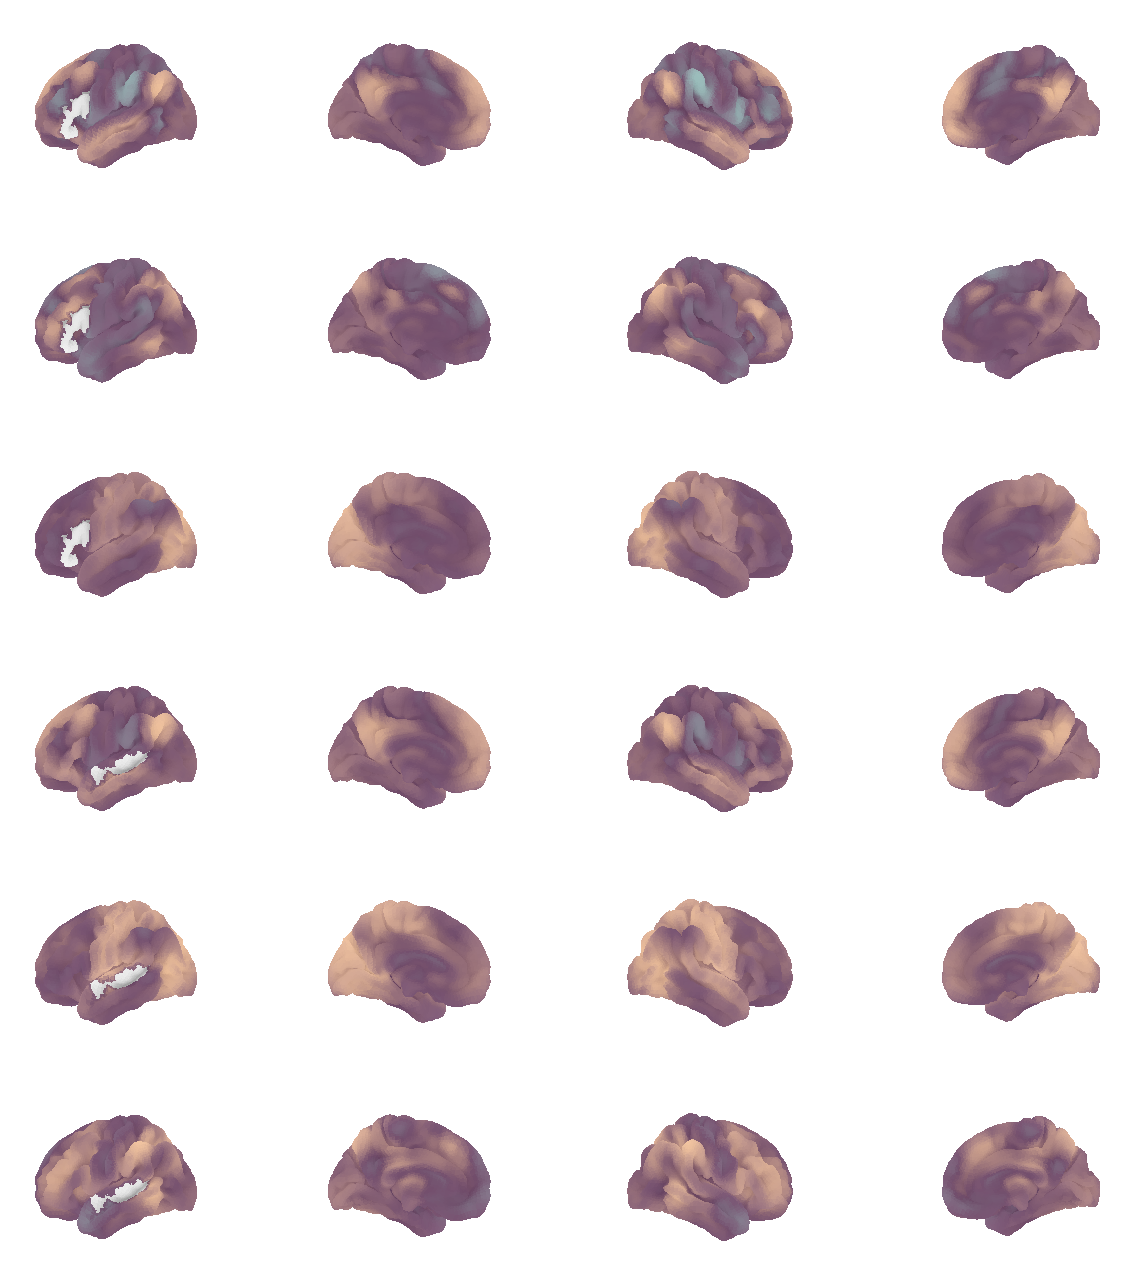

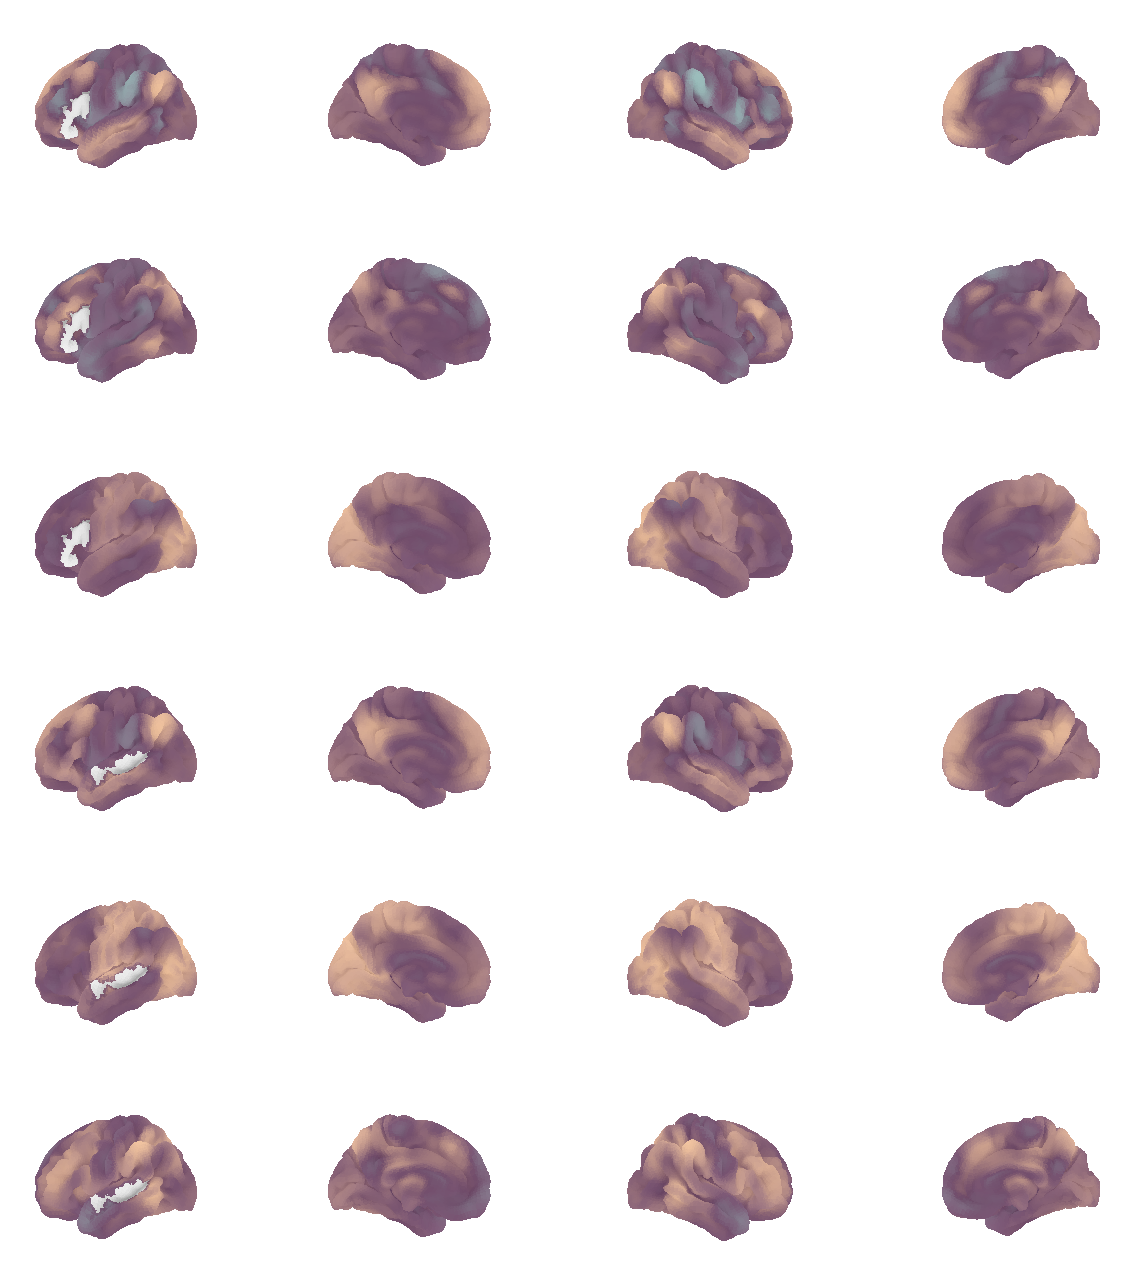

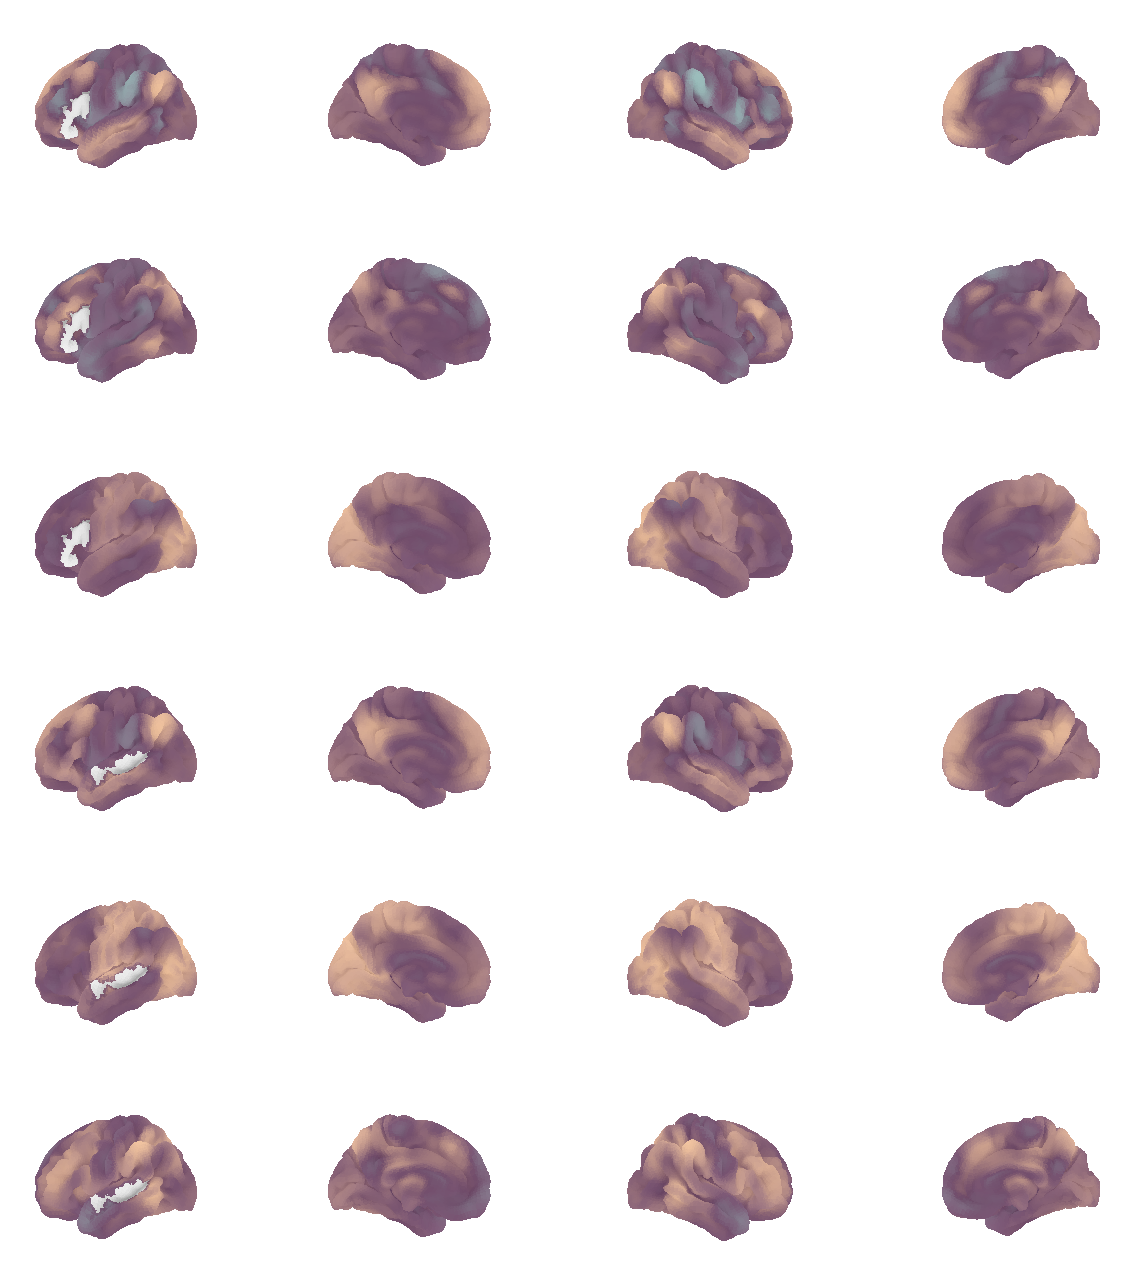

In [ ]:
colors = ["#80BBB4",  "#4B1742", "#F7B682"]
#colors = [ '#ED6B06',  "whitesmoke", '#00786A']
#color_list_comps = ['#80BBB4', ,, '#F7B682', , ]
#colors = ["#214D9D", "whitesmoke",  "#00786A"]
palette = LinearSegmentedColormap.from_list("custom_palette", colors)
cmap_new = ["#7F206E", "#EEEEEE", "#00483F" ]
#colors = ["#214D9D", "whitesmoke", "#AA1926"]
cmap1 = LinearSegmentedColormap.from_list("mycmap", cmap_new)

nifti_path = r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\to_laptop\ic_maps"
lifg_img = os.path.join(nifti_path, "g1_pmap_lifg_oIC.nii.gz")
lstg_img = os.path.join(nifti_path, "g1_pmap_lstg_oIC.nii.gz")

nii_files = [image.index_img(lifg_img, 0),
             image.index_img(lifg_img, 1),
             image.index_img(lifg_img, 2),
             image.index_img(lstg_img, 0),
             image.index_img(lstg_img, 1),
             image.index_img(lstg_img, 2)]

masks_files = [os.path.join(base_dir, "masks", "roi_lifg.nii.gz"),
               os.path.join(base_dir, "masks", "roi_lifg.nii.gz"),
               os.path.join(base_dir, "masks", "roi_lifg.nii.gz"),
               os.path.join(base_dir, "masks", "roi_lstg.nii.gz"),
               os.path.join(base_dir, "masks", "roi_lstg.nii.gz"), 
               os.path.join(base_dir, "masks", "roi_lstg.nii.gz")]

print(len(nii_files))
print(len(masks_files))

plot_surface_maps_fig_1(img_list = nii_files,
                         mask_list= masks_files,
                        cmap_list = [palette] * len(nii_files),
                        pmap_mask= [True] * len(nii_files), 
                        output_file=os.path.join(base_dir, "figs_new", "fig_2_ics_g1.png"),
                        thresholds=[1e-6] * len(nii_files))


plot_surface_maps_fig_1(img_list = nii_files,
                         mask_list= masks_files,
                        cmap_list = [palette] * len(nii_files),
                        pmap_mask= [True] * len(nii_files), 
                        output_file=os.path.join(base_dir, "figs_new", "fig_2_ics_g1.svg"),
                        thresholds=[1e-6] * len(nii_files))

6
6
6655.9482421875
6645.923828125
4052.612548828125
5996.78076171875
3538.814697265625
3891.433837890625
6655.9482421875
6645.923828125
4052.612548828125
5996.78076171875
3538.814697265625
3891.433837890625


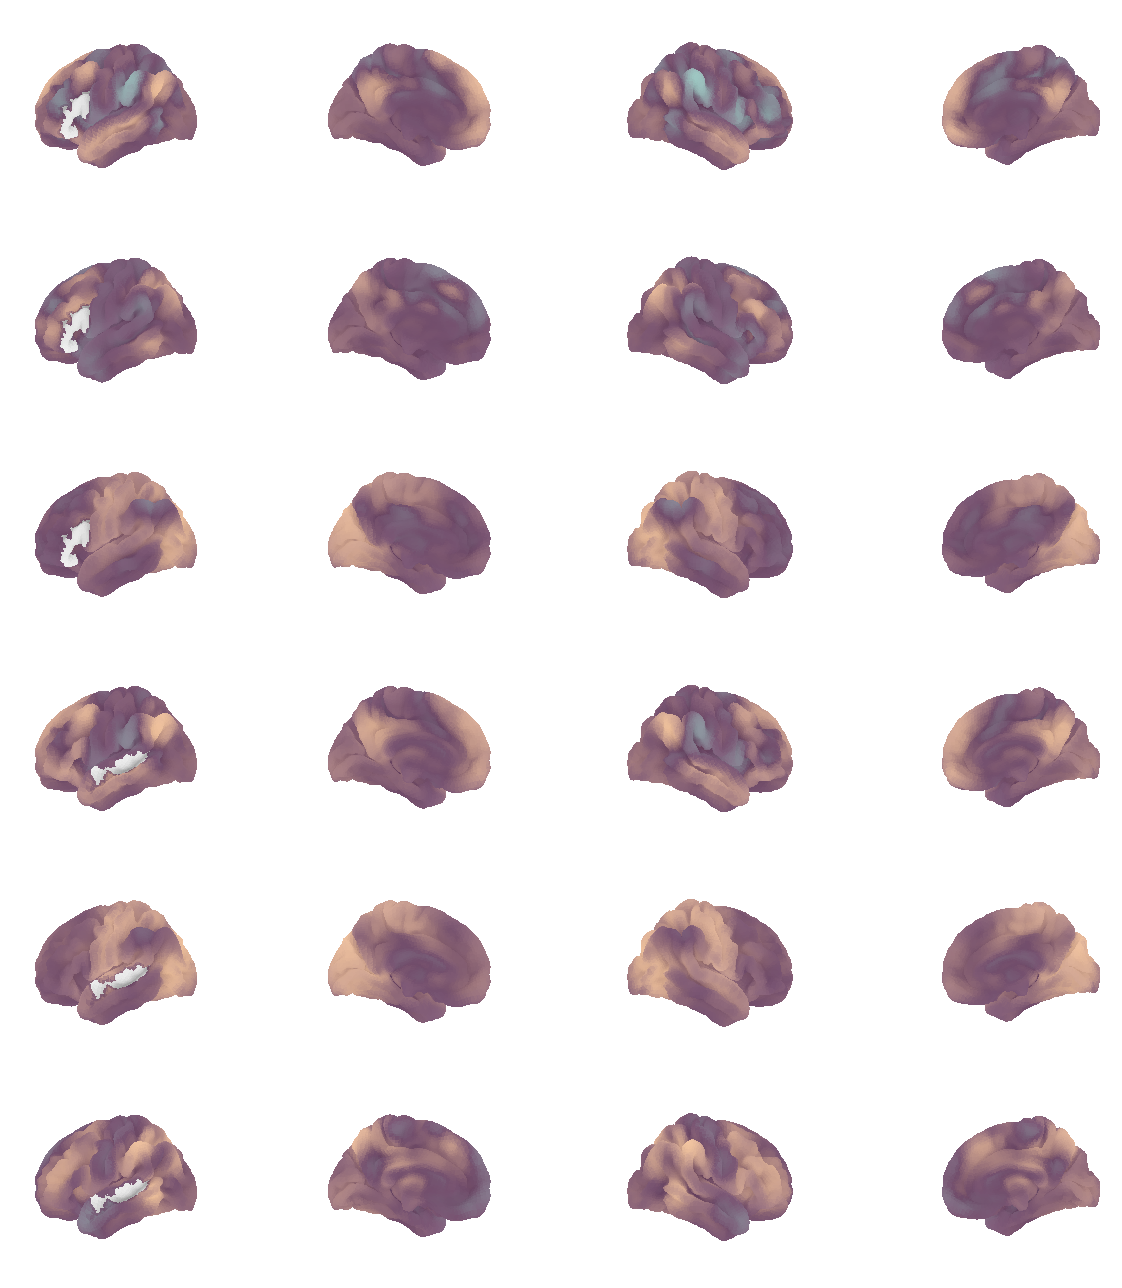

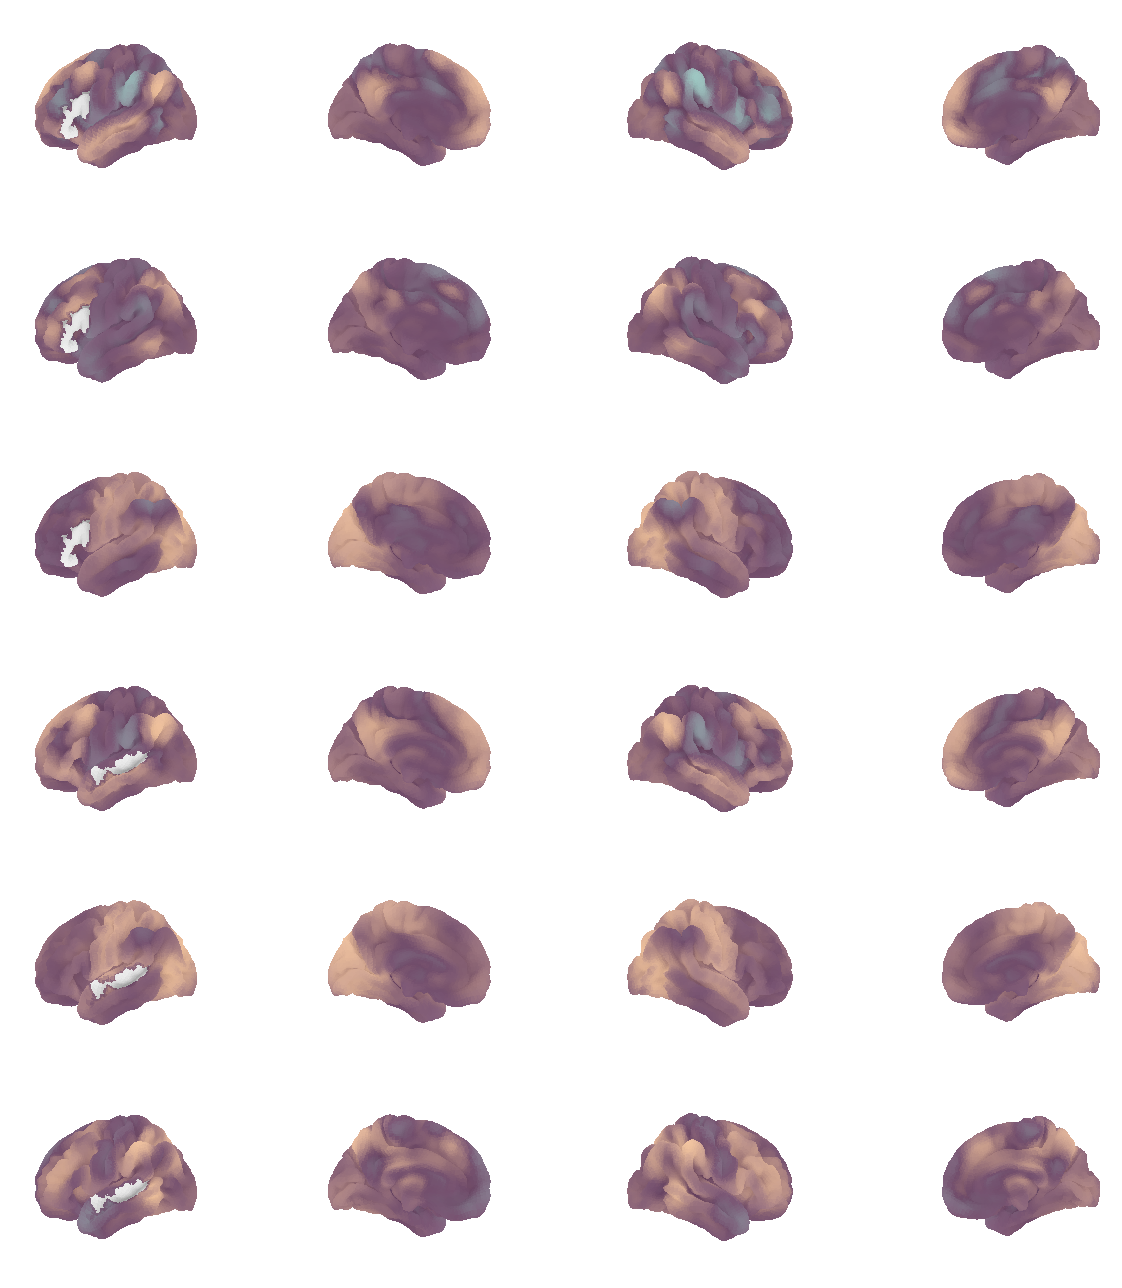

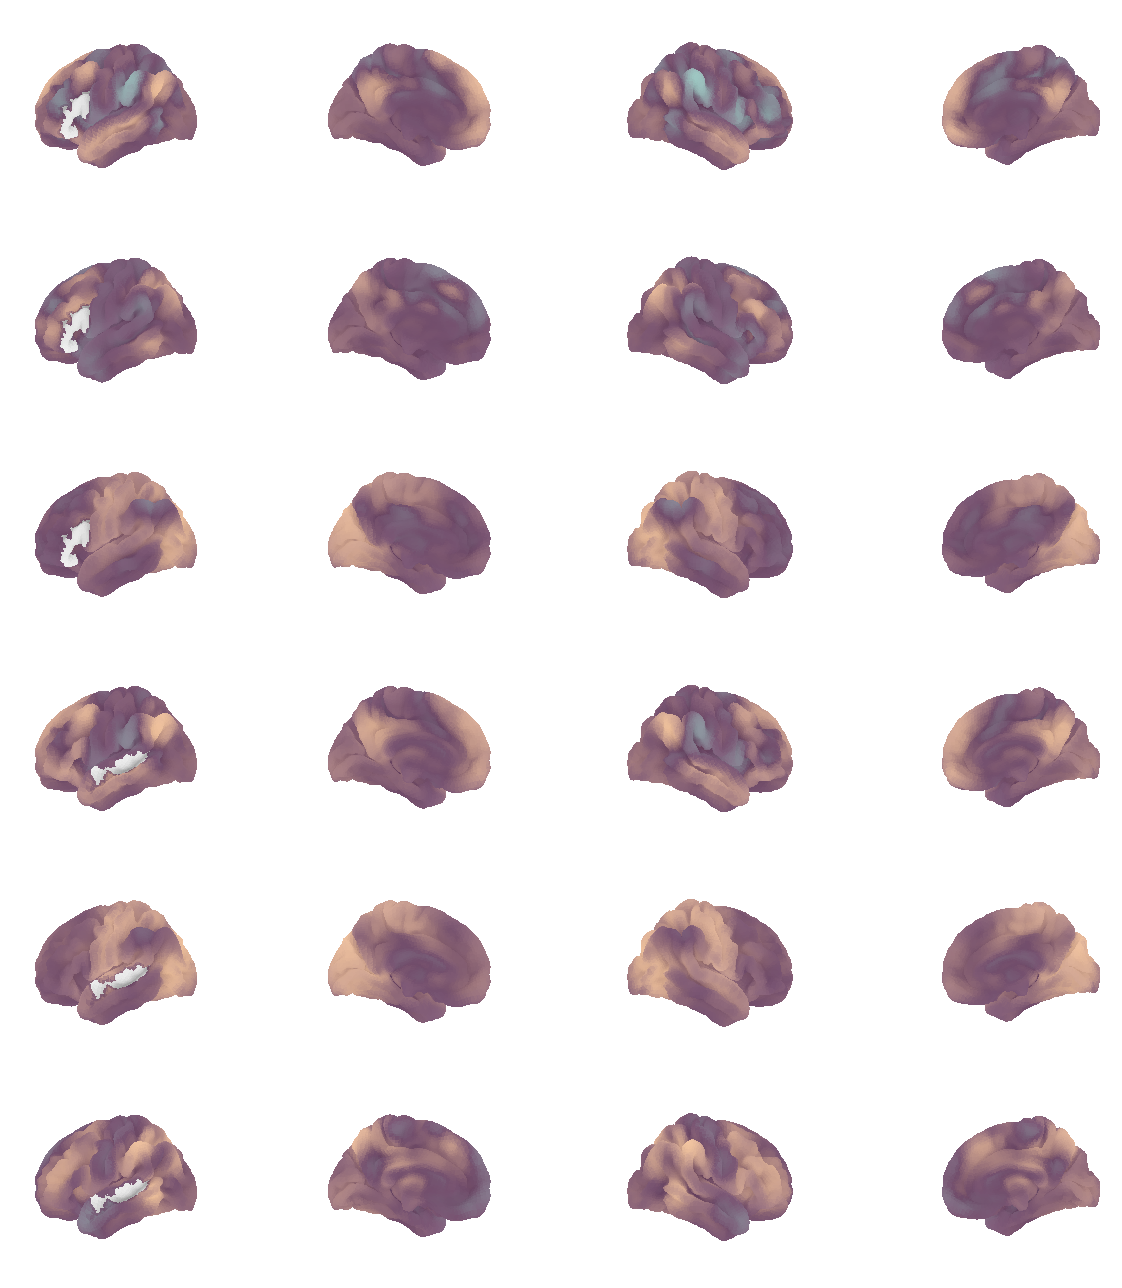

In [ ]:
colors = ["#80BBB4",  "#4B1742", "#F7B682"]
#colors = [ '#ED6B06',  "whitesmoke", '#00786A']
#color_list_comps = ['#80BBB4', ,, '#F7B682', , ]
#colors = ["#214D9D", "whitesmoke",  "#00786A"]
palette = LinearSegmentedColormap.from_list("custom_palette", colors)
cmap_new = ["#7F206E", "#EEEEEE", "#00483F" ]
#colors = ["#214D9D", "whitesmoke", "#AA1926"]
cmap1 = LinearSegmentedColormap.from_list("mycmap", cmap_new)

lifg_img = os.path.join(nifti_path, "g2_pmap_lifg_oIC.nii.gz")
lstg_img = os.path.join(nifti_path, "g2_pmap_lstg_oIC.nii.gz")

nii_files = [image.index_img(lifg_img, 0),
             image.index_img(lifg_img, 1),
             image.index_img(lifg_img, 2),
             image.index_img(lstg_img, 0),
             image.index_img(lstg_img, 1),
             image.index_img(lstg_img, 2)]

masks_files = [os.path.join(base_dir, "masks", "roi_lifg.nii.gz"),
               os.path.join(base_dir, "masks", "roi_lifg.nii.gz"),
               os.path.join(base_dir, "masks", "roi_lifg.nii.gz"),
               os.path.join(base_dir, "masks", "roi_lstg.nii.gz"),
               os.path.join(base_dir, "masks", "roi_lstg.nii.gz"), 
               os.path.join(base_dir, "masks", "roi_lstg.nii.gz")]

print(len(nii_files))
print(len(masks_files))

plot_surface_maps_fig_1(img_list = nii_files,
                         mask_list= masks_files,
                        cmap_list = [palette] * len(nii_files),
                        pmap_mask= [True] * len(nii_files), 
                        output_file=os.path.join(base_dir, "figs_new", "fig_2_ics_g2.png"),
                        thresholds=[1e-6] * len(nii_files))


plot_surface_maps_fig_1(img_list = nii_files,
                         mask_list= masks_files,
                        cmap_list = [palette] * len(nii_files),
                        pmap_mask= [True] * len(nii_files), 
                        output_file=os.path.join(base_dir, "figs_new", "fig_2_ics_g2.svg"),
                        thresholds=[1e-6] * len(nii_files))